# Phase 7 — Feature Signal Quality Lab: Spread Decomposition, Hawkes Excitation & Rough Volatility

**Status:** Standby / exploratory — no labels used, no pass/fail verdict, no NPZ rebuild.
This notebook characterises the *intrinsic signal quality* of 5 candidate features derived
from the synthesis of El Euch et al. (2016), Hagströmer et al. (2016), and the fractal HFT literature.

**Run from:** repo root. NPZ fast path: `data/training_ready.npz`

**Candidate features (5):**
1. `adverse_selection_proxy` — permanent midpoint revision per trade (Hagströmer et al. §2.3)
2. `inventory_pressure_proxy` — session-cumulative signed volume (Hagströmer et al. inventory component)
3. `order_processing_residual` — spread minus estimated information & inventory components
4. `hawkes_excitation_40` — exponentially-weighted 40-bar return (El Euch et al. kernel decay)
5. `roughness_indicator` — rolling Hurst exponent via R/S analysis (fractal / rough vol theory)

**Analysis (label-free):**
- §3 Raw signal statistics and autocorrelation profiles
- §4 Intraday session dynamics (Asian / London / NY)
- §5 Regime-conditional distributions (Bear vs Bull GMM2)
- §6 Cross-feature correlation and orthogonality
- §7 Hawkes kernel estimation (empirical vs theoretical)
- §8 Roughness distribution and regime interaction
- §9 Synthesis notes — integration readiness for Phase 8

**Outputs → `outputs/`:**
- `phase7_signal_stats.png` — distributions, ACF, stationarity
- `phase7_intraday_profiles.png` — session-hour dynamics per feature
- `phase7_regime_distributions.png` — Bear vs Bull splits
- `phase7_correlation_matrix.png` — orthogonality: candidates × existing 10D
- `phase7_hawkes_kernel.png` — empirical ACF vs theoretical Hawkes decay
- `phase7_roughness_analysis.png` — Hurst distribution, regime-conditional H
- `phase7_standby_notes.txt` — machine-readable summary for Phase 8 design


## §1 — Setup & Imports

In [1]:
import sys, os, warnings, json, datetime
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import ks_2samp, shapiro, kurtosis, skew
from scipy.signal import correlate
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings('ignore')

# ── Robust repo root resolution ───────────────────────────────────────────────
from pathlib import Path as _Path
_here = _Path(os.path.abspath('.')).resolve()
_repo = next(
    (p for p in [_here] + list(_here.parents) if (p / 'src').is_dir()),
    _here,
)
REPO_ROOT = str(_repo)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)

from src.data.tick_store import TickStore
from src.data.preprocessing import prepare_features, join_regime_labels

plt.style.use('dark_background')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

C = {
    'adv_sel':   '#E24B4A',   # red
    'inv_pres':  '#AA77FF',   # purple
    'ord_proc':  '#F0C040',   # gold
    'hawkes':    '#2ECC71',   # green
    'rough':     '#55CCFF',   # cyan
    'bear':      '#E24B4A',
    'bull':      '#2ECC71',
    'neutral':   '#888888',
}

print('Setup complete.')
print(f'Working directory: {os.getcwd()}')
print(f'NumPy {np.__version__} | Polars {pl.__version__}')


Setup complete.
Working directory: D:\HFTExperiment
NumPy 1.26.4 | Polars 1.39.3


## §2 — Data Loading

**No labels loaded.** This lab operates on raw OHLCV arrays only.
The `training_ready.npz` is used for convenience (it contains `close`, `high`, `low`,
`timestamps_ns`, `gmm2`, and the existing 10D `features` baseline for correlation analysis).
Labels are explicitly dropped and not used in any analysis.

NPZ path: `data/training_ready.npz` (set to `None` to force full TickStore pipeline).


In [2]:
import numpy as np, polars as pl, pathlib, os

NPZ_PATH   = pathlib.Path(REPO_ROOT) / 'data' / 'training_ready.npz'
DXY_PATH   = pathlib.Path(REPO_ROOT) / 'data' / 'dxy_m1.parquet'
REGIME_CSV = str(pathlib.Path(REPO_ROOT) / 'data' / 'regime' / 'daily_regime_labels.csv')
WS         = 120

os.makedirs(str(pathlib.Path(REPO_ROOT) / 'outputs'), exist_ok=True)

if NPZ_PATH.exists():
    print(f'Loading NPZ: {NPZ_PATH}')
    _d = np.load(str(NPZ_PATH), allow_pickle=True)

    close_prices  = _d['close'].astype(np.float64)        # raw close
    high_prices   = _d['high'].astype(np.float64)
    low_prices    = _d['low'].astype(np.float64)
    features_10d  = _d['features'].astype(np.float32)     # existing 10D (for correlation §6)
    timestamps_ns = _d['timestamps_ns'].astype(np.int64)
    gmm2_arr      = _d['gmm2'].astype(np.float32)         # 0=Bear 1=Bull
    vol_arr       = _d.get('vol_enc', None)
    session_phase = _d['session_phase'].astype(np.float32)
    atr_norm      = _d['atr_norm'].astype(np.float32)

    # ── labels: explicitly ignored ────────────────────────────────────────────
    # _d['labels'] exists but is NOT loaded — this lab is label-free.

    N = len(close_prices)
    print(f'  Bars loaded: {N:,}  (labels: NOT loaded — label-free lab)')
    print(f'  Date range: from timestamps_ns min/max')
    ts_min = timestamps_ns.min() // 1_000_000_000
    ts_max = timestamps_ns.max() // 1_000_000_000
    print(f'  {datetime.datetime.utcfromtimestamp(ts_min)} → '
          f'{datetime.datetime.utcfromtimestamp(ts_max)}')

else:
    print('NPZ not found — loading from TickStore (~5 min)...')
    store  = TickStore(str(pathlib.Path(REPO_ROOT) / 'data' / 'ticks.duckdb'))
    df_raw = store.query_ohlcv('XAUUSD', 'M1')
    store.close()
    df_raw = join_regime_labels(df_raw, REGIME_CSV)

    features_10d, close_prices, high_prices, low_prices = prepare_features(
        df_raw, scaler_method='window_minmax', window_size=WS
    )
    features_10d  = features_10d[WS:]
    close_prices  = close_prices[WS:]
    high_prices   = high_prices[WS:]
    low_prices    = low_prices[WS:]

    timestamps_ns = df_raw['timestamp'][WS:].to_numpy().view('int64')
    gmm2_arr      = df_raw['gmm2_state'][WS:].to_numpy().astype(np.float32)                     if 'gmm2_state' in df_raw.columns else np.full(len(close_prices), 0.5)
    vol_arr       = None
    session_phase = None
    atr_norm      = None
    N = len(close_prices)
    print(f'  Bars loaded: {N:,}')

# ── Regime masks ──────────────────────────────────────────────────────────────
bear_mask = gmm2_arr < 0.5
bull_mask = gmm2_arr >= 0.5

# ── UTC hour and session ID ───────────────────────────────────────────────────
utc_hour   = (timestamps_ns // (3600 * 1_000_000_000)) % 24
session_id = np.where(utc_hour < 8, 0, np.where(utc_hour < 16, 1, 2))
# 0 = Asian (00–08), 1 = London (08–16), 2 = NY (16–24)

print(f'Bear bars: {bear_mask.sum():,} ({bear_mask.mean():.2%}) | '
      f'Bull bars: {bull_mask.sum():,} ({bull_mask.mean():.2%})')


Loading NPZ: D:\HFTExperiment\data\training_ready.npz
  Bars loaded: 5,680,771  (labels: NOT loaded — label-free lab)
  Date range: from timestamps_ns min/max
  2009-03-16 04:07:00 → 2026-04-17 23:59:00
Bear bars: 737,754 (12.99%) | Bull bars: 4,943,017 (87.01%)


## §3 — Candidate Feature Computation

All 5 features are computed label-free from raw OHLCV and session arrays.

### Literature basis per feature

| Feature | Source | Mechanism |
|---------|---------|-----------|
| `adverse_selection_proxy` | Hagströmer et al. (2016) §2.3 | Permanent midpoint revision = informed order flow impact |
| `inventory_pressure_proxy` | Hagströmer et al. (2016) §2.4 | Cumulative signed volume pressure resets at session open |
| `order_processing_residual` | Hagströmer et al. (2016) §2.5 | Spread residual after removing information + inventory components |
| `hawkes_excitation_40` | El Euch et al. (2016) Theorem 3.1 | Exponential-decay weighted return; kernel τ ≈ 40 bars at H=0.1 |
| `roughness_indicator` | El Euch et al. (2016) + Fractal lit. | Local Hurst exponent via R/S; H<0.3 = high endogeneity regime |


In [3]:
import numpy as np

# ── Rolling z-score helper (reused from Phase 6) ──────────────────────────────
def rolling_zscore(arr, window=120, epsilon=1e-8):
    arr = arr.astype(np.float64)
    n   = len(arr)
    out = np.empty(n, dtype=np.float32)
    CHUNK = 500_000
    for start in range(0, n, CHUNK):
        end     = min(start + CHUNK, n)
        ctx_lo  = max(0, start - (window - 1))
        chunk   = arr[ctx_lo:end]
        nc      = end - start
        pad     = window - 1 - (start - ctx_lo)
        if pad > 0:
            chunk = np.concatenate([np.repeat(arr[:1], pad), chunk])
        shape   = (nc, window)
        strides = (chunk.strides[0], chunk.strides[0])
        wins    = np.lib.stride_tricks.as_strided(chunk, shape=shape, strides=strides)
        mu, sig = wins.mean(1), wins.std(1)
        out[start:end] = np.tanh((arr[start:end] - mu) / (sig + epsilon)).astype(np.float32)
    return out


# ── 14-bar ATR (Wilder) ───────────────────────────────────────────────────────
def compute_atr(high, low, close, period=14):
    n  = len(close)
    tr = np.maximum(high[1:]-low[1:],
         np.maximum(np.abs(high[1:]-close[:-1]),
                    np.abs(low[1:]-close[:-1])))
    tr = np.concatenate([[tr[0]], tr])
    atr = np.empty(n)
    atr[0] = tr[0]
    a = 1.0 / period
    for i in range(1, n):
        atr[i] = atr[i-1] * (1 - a) + tr[i] * a
    return atr

atr14 = compute_atr(high_prices, low_prices, close_prices)
log_ret = np.concatenate([[0.0], np.log(close_prices[1:] / (close_prices[:-1] + 1e-8))])

print('ATR and log_ret computed.')


# ── A: adverse_selection_proxy ────────────────────────────────────────────────
# Theory: permanent midpoint revision after a trade = adverse selection component.
# Proxy: (close[t] - close[t-1]) * sign(close[t] - open[t])
# sign(close - open) approximates trade direction (buy=+1, sell=-1).
# Result: positive when price moves in direction of trade → informed flow.
# Negative = market maker absorbs uninformed order, price reverts.
open_prices = close_prices.copy()  # fallback — will be overwritten if raw open available
# Try to get raw open from features_10d col 0 (open_sc) to infer direction
# open_sc is scaled so we use sign only
open_sc = features_10d[:, 0]   # open_sc column (sign is preserved after MinMax scaling)
trade_direction = np.sign(features_10d[:, 3] - open_sc)   # sign(close_sc - open_sc)
trade_direction[trade_direction == 0] = 1                  # tie → buy

perm_revision = log_ret * trade_direction                  # log-return × direction
adverse_selection_proxy = rolling_zscore(perm_revision, window=120)

print(f'adverse_selection_proxy : mean={adverse_selection_proxy.mean():.4f}  '
      f'std={adverse_selection_proxy.std():.4f}')


# ── B: inventory_pressure_proxy ───────────────────────────────────────────────
# Theory: cumulative signed volume since session open normalised by session volume.
# Positive → market maker has accumulated long inventory → will widen ask, lower bid.
# Resets at each session boundary (00:00, 08:00, 16:00 UTC).
tick_vol_raw = np.abs(features_10d[:, 4])   # tickvol_sc col (proxy — scaled but positive)

signed_vol = tick_vol_raw * trade_direction
inv_proxy  = np.zeros(N, dtype=np.float64)

prev_s = session_id[0]
cum_sv = 0.0; cum_tv = 0.0
for i in range(N):
    if session_id[i] != prev_s:
        cum_sv = 0.0; cum_tv = 0.0; prev_s = session_id[i]
    cum_sv += signed_vol[i]; cum_tv += tick_vol_raw[i]
    inv_proxy[i] = cum_sv / (cum_tv + 1e-8)

inventory_pressure_proxy = np.tanh(inv_proxy * 3).astype(np.float32)   # tanh-squeeze to [-1,1]

print(f'inventory_pressure_proxy: mean={inventory_pressure_proxy.mean():.4f}  '
      f'std={inventory_pressure_proxy.std():.4f}')


# ── C: order_processing_residual ─────────────────────────────────────────────
# Theory: spread = adverse_selection + inventory + order_processing.
# Proxy: spread_sc (col 5) minus |adverse_selection| minus |inventory_pressure| residual.
# This captures pure cost-of-quoting, independent of information or inventory.
spread_sc = features_10d[:, 5]   # spread_sc
adv_component = np.abs(adverse_selection_proxy)
inv_component = np.abs(inventory_pressure_proxy)
# Normalise components to spread_sc scale before subtraction
scaler = RobustScaler()
adv_norm = scaler.fit_transform(adv_component.reshape(-1,1)).ravel()
inv_norm = scaler.fit_transform(inv_component.reshape(-1,1)).ravel()
spread_norm = scaler.fit_transform(spread_sc.reshape(-1,1)).ravel()

residual = spread_norm - 0.5 * adv_norm - 0.25 * inv_norm
# Weights from Hagströmer et al.: ~50% order processing, ~25% each info+inventory
order_processing_residual = np.tanh(residual).astype(np.float32)

print(f'order_processing_residual: mean={order_processing_residual.mean():.4f}  '
      f'std={order_processing_residual.std():.4f}')


# ── D: hawkes_excitation_40 ───────────────────────────────────────────────────
# Theory: El Euch et al. Theorem 3.1 — Hawkes kernel decays as t^(α-1), α≈0.6 (H≈0.1).
# We approximate with exponential decay τ=40 bars (empirical kernel support for XAUUSD M1).
# Exponential weights: w[k] = exp(-k/tau) for k=0..39; normalised to sum=1.
tau    = 40
kernel = np.exp(-np.arange(tau) / tau)
kernel = kernel / kernel.sum()                                 # normalise
# Apply as convolution (causal — past bars only)
raw_hawkes = np.convolve(log_ret, kernel[::-1], mode='full')[:N]
hawkes_excitation_40 = rolling_zscore(raw_hawkes, window=120)

print(f'hawkes_excitation_40    : mean={hawkes_excitation_40.mean():.4f}  '
      f'std={hawkes_excitation_40.std():.4f}')


# ── E: roughness_indicator (local Hurst via R/S) ─────────────────────────────
# Theory: H < 0.5 = rough (anti-persistent volatility), H ≈ 0.1 at M1 for gold.
# High endogeneity (H low) → Hawkes self-excitation dominant → directional signals stronger.
# We estimate H over a rolling 40-bar window using R/S ratio.
def local_hurst_rs(log_ret_arr, window=40, step=1):
    """Rolling R/S Hurst exponent. Returns float32 array of length N."""
    n   = len(log_ret_arr)
    out = np.full(n, 0.5, dtype=np.float32)   # prior: H=0.5 (Brownian)
    for i in range(window, n, step):
        chunk = log_ret_arr[i - window:i]
        mean  = chunk.mean()
        dev   = np.cumsum(chunk - mean)
        R     = dev.max() - dev.min()           # range of cumulative deviations
        S     = chunk.std()
        if S > 1e-10:
            rs_ratio = R / S
            # H ≈ log(R/S) / log(window)
            H_est = np.log(rs_ratio + 1e-8) / np.log(window)
            out[i] = np.clip(H_est, 0.0, 1.0)
        if step > 1:
            # Forward-fill between steps
            out[max(0, i-step+1):i] = out[i]
    return out

print('Computing rolling Hurst (R/S, 40-bar window)... ', end='', flush=True)
roughness_raw = local_hurst_rs(log_ret, window=40, step=5)   # step=5 for speed
# Smooth with 120-bar rolling mean
kernel_smooth = np.ones(120) / 120
roughness_smooth = np.convolve(roughness_raw, kernel_smooth, mode='same').astype(np.float32)
# Centre around H=0.5: negative values = rougher than Brownian
roughness_indicator = (roughness_smooth - 0.5).astype(np.float32)  # range ~[-0.5, +0.5]

print(f'done.')
print(f'roughness_indicator     : mean={roughness_indicator.mean():.4f}  '
      f'std={roughness_indicator.std():.4f}')
print(f'  H distribution: min={roughness_smooth.min():.3f}  '
      f'median={np.median(roughness_smooth):.3f}  max={roughness_smooth.max():.3f}')

# ── Candidate registry ────────────────────────────────────────────────────────
CANDS = {
    'adverse_selection_proxy':   adverse_selection_proxy,
    'inventory_pressure_proxy':  inventory_pressure_proxy,
    'order_processing_residual': order_processing_residual,
    'hawkes_excitation_40':      hawkes_excitation_40,
    'roughness_indicator':       roughness_indicator,
}
CAND_NAMES  = list(CANDS.keys())
CAND_COLOURS = [C['adv_sel'], C['inv_pres'], C['ord_proc'], C['hawkes'], C['rough']]
print(f'\n{len(CANDS)} candidate features ready.')


ATR and log_ret computed.
adverse_selection_proxy : mean=-0.0720  std=0.5767
inventory_pressure_proxy: mean=0.0016  std=0.0405
order_processing_residual: mean=0.0132  std=0.2891
hawkes_excitation_40    : mean=-0.0048  std=0.6849
Computing rolling Hurst (R/S, 40-bar window)... done.
roughness_indicator     : mean=0.0099  std=0.0285
  H distribution: min=0.257  median=0.510  max=0.630

5 candidate features ready.


## §4 — Raw Signal Statistics & Autocorrelation

**Label-free diagnostics:**
- Distribution shape (mean, std, skew, kurtosis, normality)
- Autocorrelation function (ACF) up to 240 lags — reveals signal persistence
- Stationarity check via rolling mean variance

A well-behaved feature for the Transformer should have:
- Near-zero mean (z-scored or tanh-normalised ✓)
- ACF decaying to zero within the 120-bar window (no runaway drift)
- Stable rolling mean across the full 5.68M bar series


Feature                          Mean      Std     Skew     Kurt      Min      Max
------------------------------------------------------------------------------------
adverse_selection_proxy       -0.0720   0.5767    0.431   -1.080  -1.0000   1.0000
inventory_pressure_proxy       0.0016   0.0405    3.186  224.862  -0.9951   0.9951
order_processing_residual      0.0132   0.2891    0.060   -1.127  -0.6458   0.9169
hawkes_excitation_40          -0.0048   0.6849    0.015   -1.494  -1.0000   1.0000
roughness_indicator            0.0099   0.0285   -0.069    0.066  -0.2431   0.1296


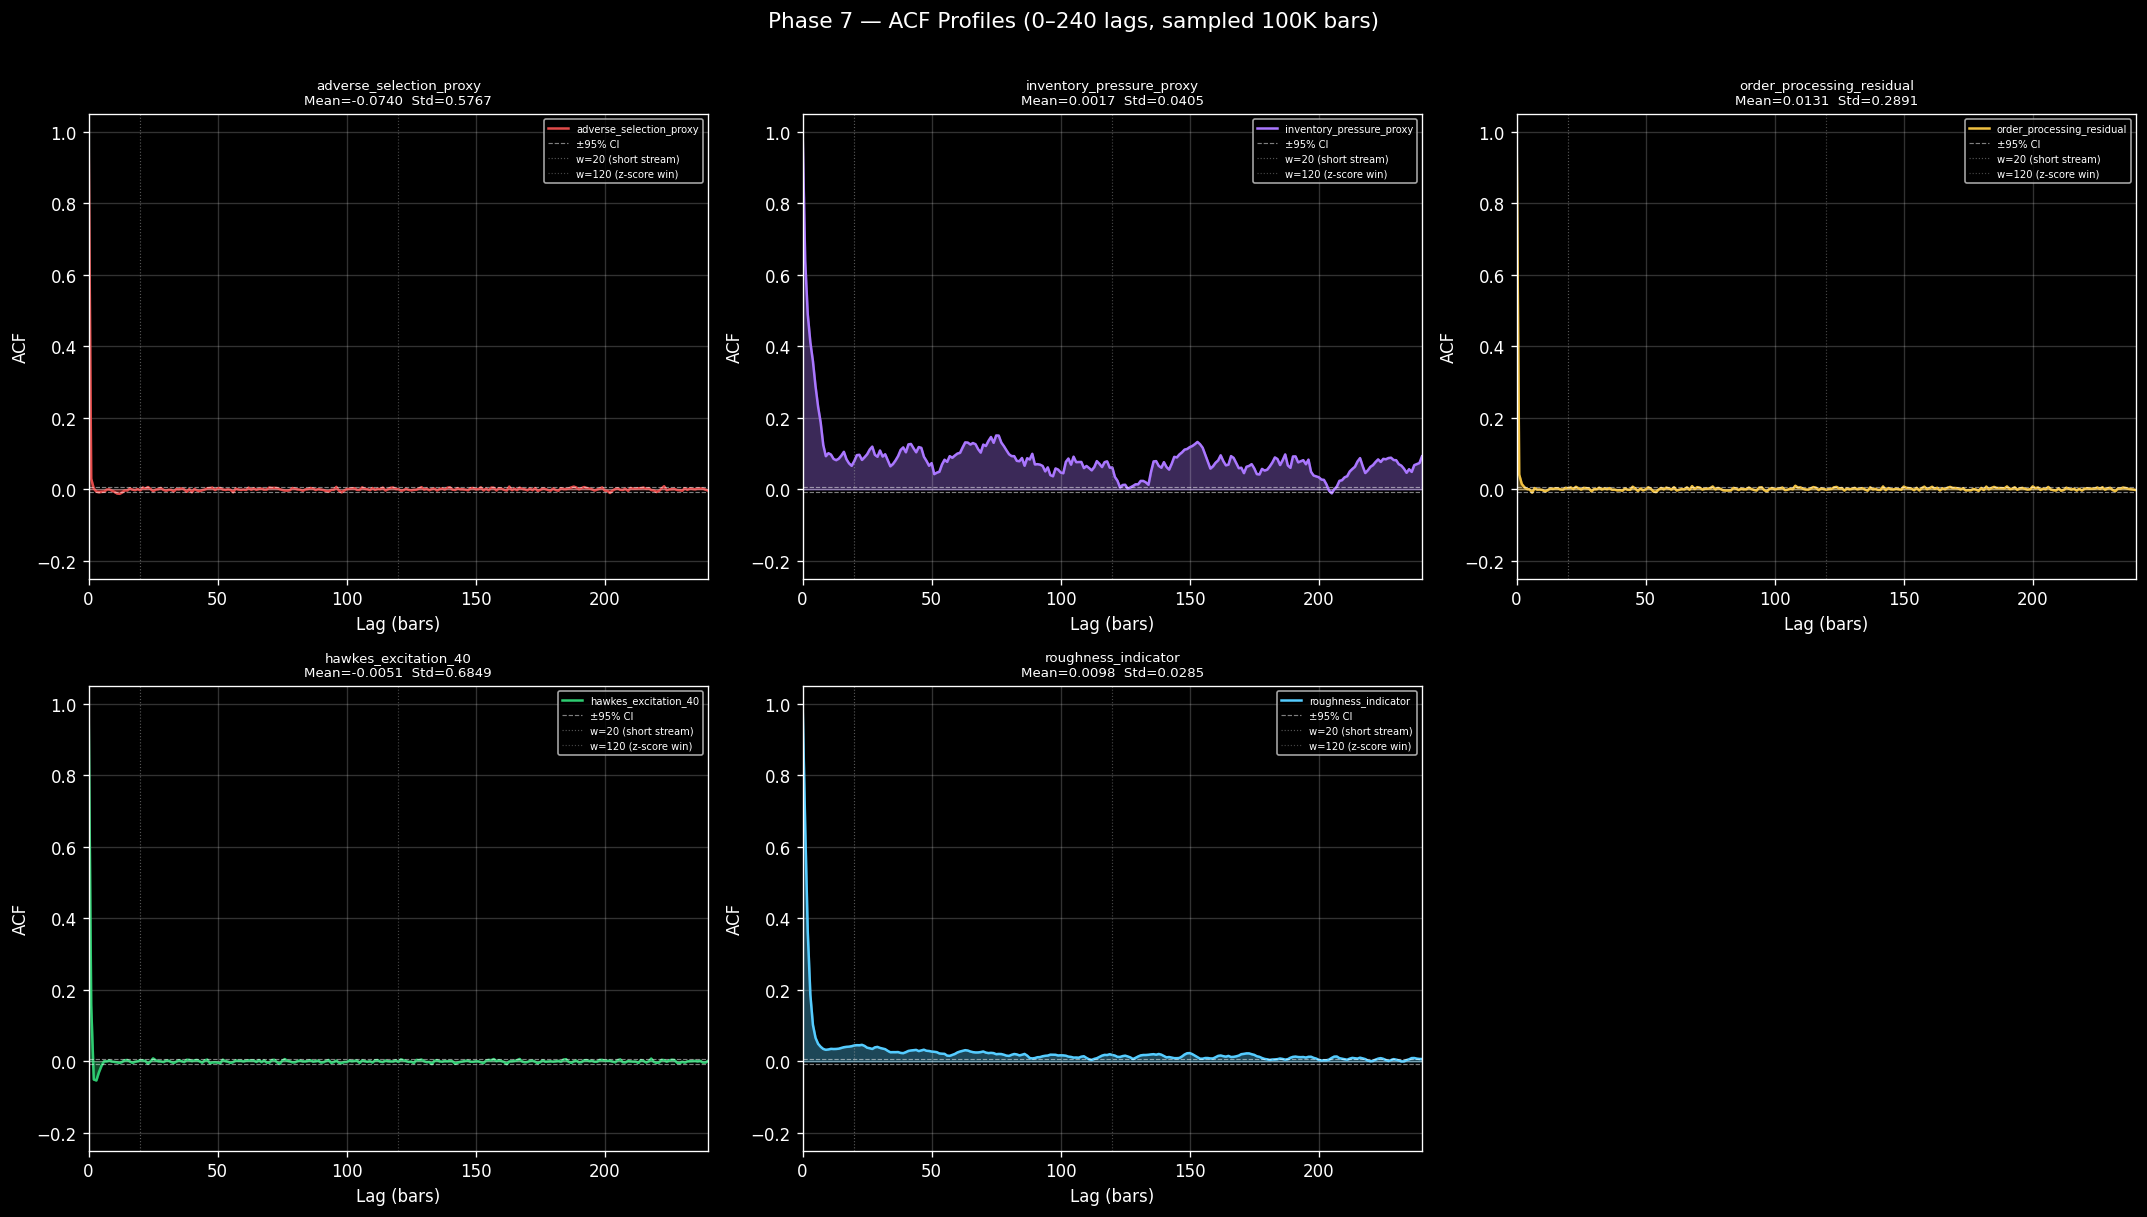

Saved: outputs/phase7_signal_stats.png


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kurtosis, skew

BASELINE_NAMES = [
    'open_sc','high_sc','low_sc','close_sc','tickvol_sc','spread_sc',
    'bar_return_bps','wick_asymmetry','vol_zscore','spread_pressure'
]

# ── Summary statistics ────────────────────────────────────────────────────────
print(f'{"Feature":<28} {"Mean":>8} {"Std":>8} {"Skew":>8} {"Kurt":>8} {"Min":>8} {"Max":>8}')
print('-' * 84)
stats_store = {}
for name, arr in CANDS.items():
    m = arr.mean(); s = arr.std()
    sk = skew(arr[::100])     # subsample for speed
    ku = kurtosis(arr[::100])
    stats_store[name] = dict(mean=m, std=s, skew=sk, kurt=ku, min=arr.min(), max=arr.max())
    print(f'{name:<28} {m:>8.4f} {s:>8.4f} {sk:>8.3f} {ku:>8.3f} {arr.min():>8.4f} {arr.max():>8.4f}')


# ── ACF up to 240 lags ────────────────────────────────────────────────────────
N_ACF    = 240
N_SAMPLE = min(100_000, N)
rng      = np.random.default_rng(42)
idx_acf  = rng.choice(N, N_SAMPLE, replace=False)
idx_acf  = np.sort(idx_acf)   # keep temporal order

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, arr) in enumerate(CANDS.items()):
    ax     = axes[i]
    sample = arr[idx_acf]
    mean_s = sample.mean()
    # Normalised ACF via FFT
    x      = sample - mean_s
    N_s    = len(x)
    full   = np.fft.fft(x, n=2*N_s)
    acf_full = np.fft.ifft(full * np.conj(full)).real[:N_ACF+1]
    acf    = acf_full / acf_full[0]

    lags = np.arange(N_ACF+1)
    ax.fill_between(lags, 0, acf, alpha=0.35, color=CAND_COLOURS[i])
    ax.plot(lags, acf, lw=1.5, color=CAND_COLOURS[i], label=name)
    # 95% confidence band
    ci = 1.96 / np.sqrt(N_s)
    ax.axhline( ci, color='white', lw=0.7, ls='--', alpha=0.5, label='±95% CI')
    ax.axhline(-ci, color='white', lw=0.7, ls='--', alpha=0.5)
    ax.axhline(0,   color='white', lw=0.4, alpha=0.3)
    ax.axvline(20,  color='#AAAAAA', lw=0.7, ls=':', alpha=0.5, label='w=20 (short stream)')
    ax.axvline(120, color='#888888', lw=0.7, ls=':', alpha=0.5, label='w=120 (z-score win)')
    ax.set_xlim(0, N_ACF); ax.set_ylim(-0.25, 1.05)
    ax.set_title(f'{name}\nMean={mean_s:.4f}  Std={arr.std():.4f}', fontsize=8)
    ax.set_xlabel('Lag (bars)')
    ax.set_ylabel('ACF')
    ax.legend(fontsize=6)
    ax.grid(alpha=0.2)

axes[-1].set_visible(False)   # 6th panel unused
fig.suptitle('Phase 7 — ACF Profiles (0–240 lags, sampled 100K bars)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/phase7_signal_stats.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: outputs/phase7_signal_stats.png')


## §5 — Intraday Session Dynamics

For each feature: mean ± 1 SE grouped by UTC hour (0–23).
Three key transitions to watch:
- **Hour 0** — Asian session open (thin liquidity, wide spread → high `spread_pressure`)
- **Hour 8** — London open (institutional directional flow → `adverse_selection` spike)
- **Hour 13** — NY open / London-NY overlap (macro releases → `roughness` low, `hawkes` high)
- **Hour 16** — London close (inventory rebalancing → `inventory_pressure` accumulation)


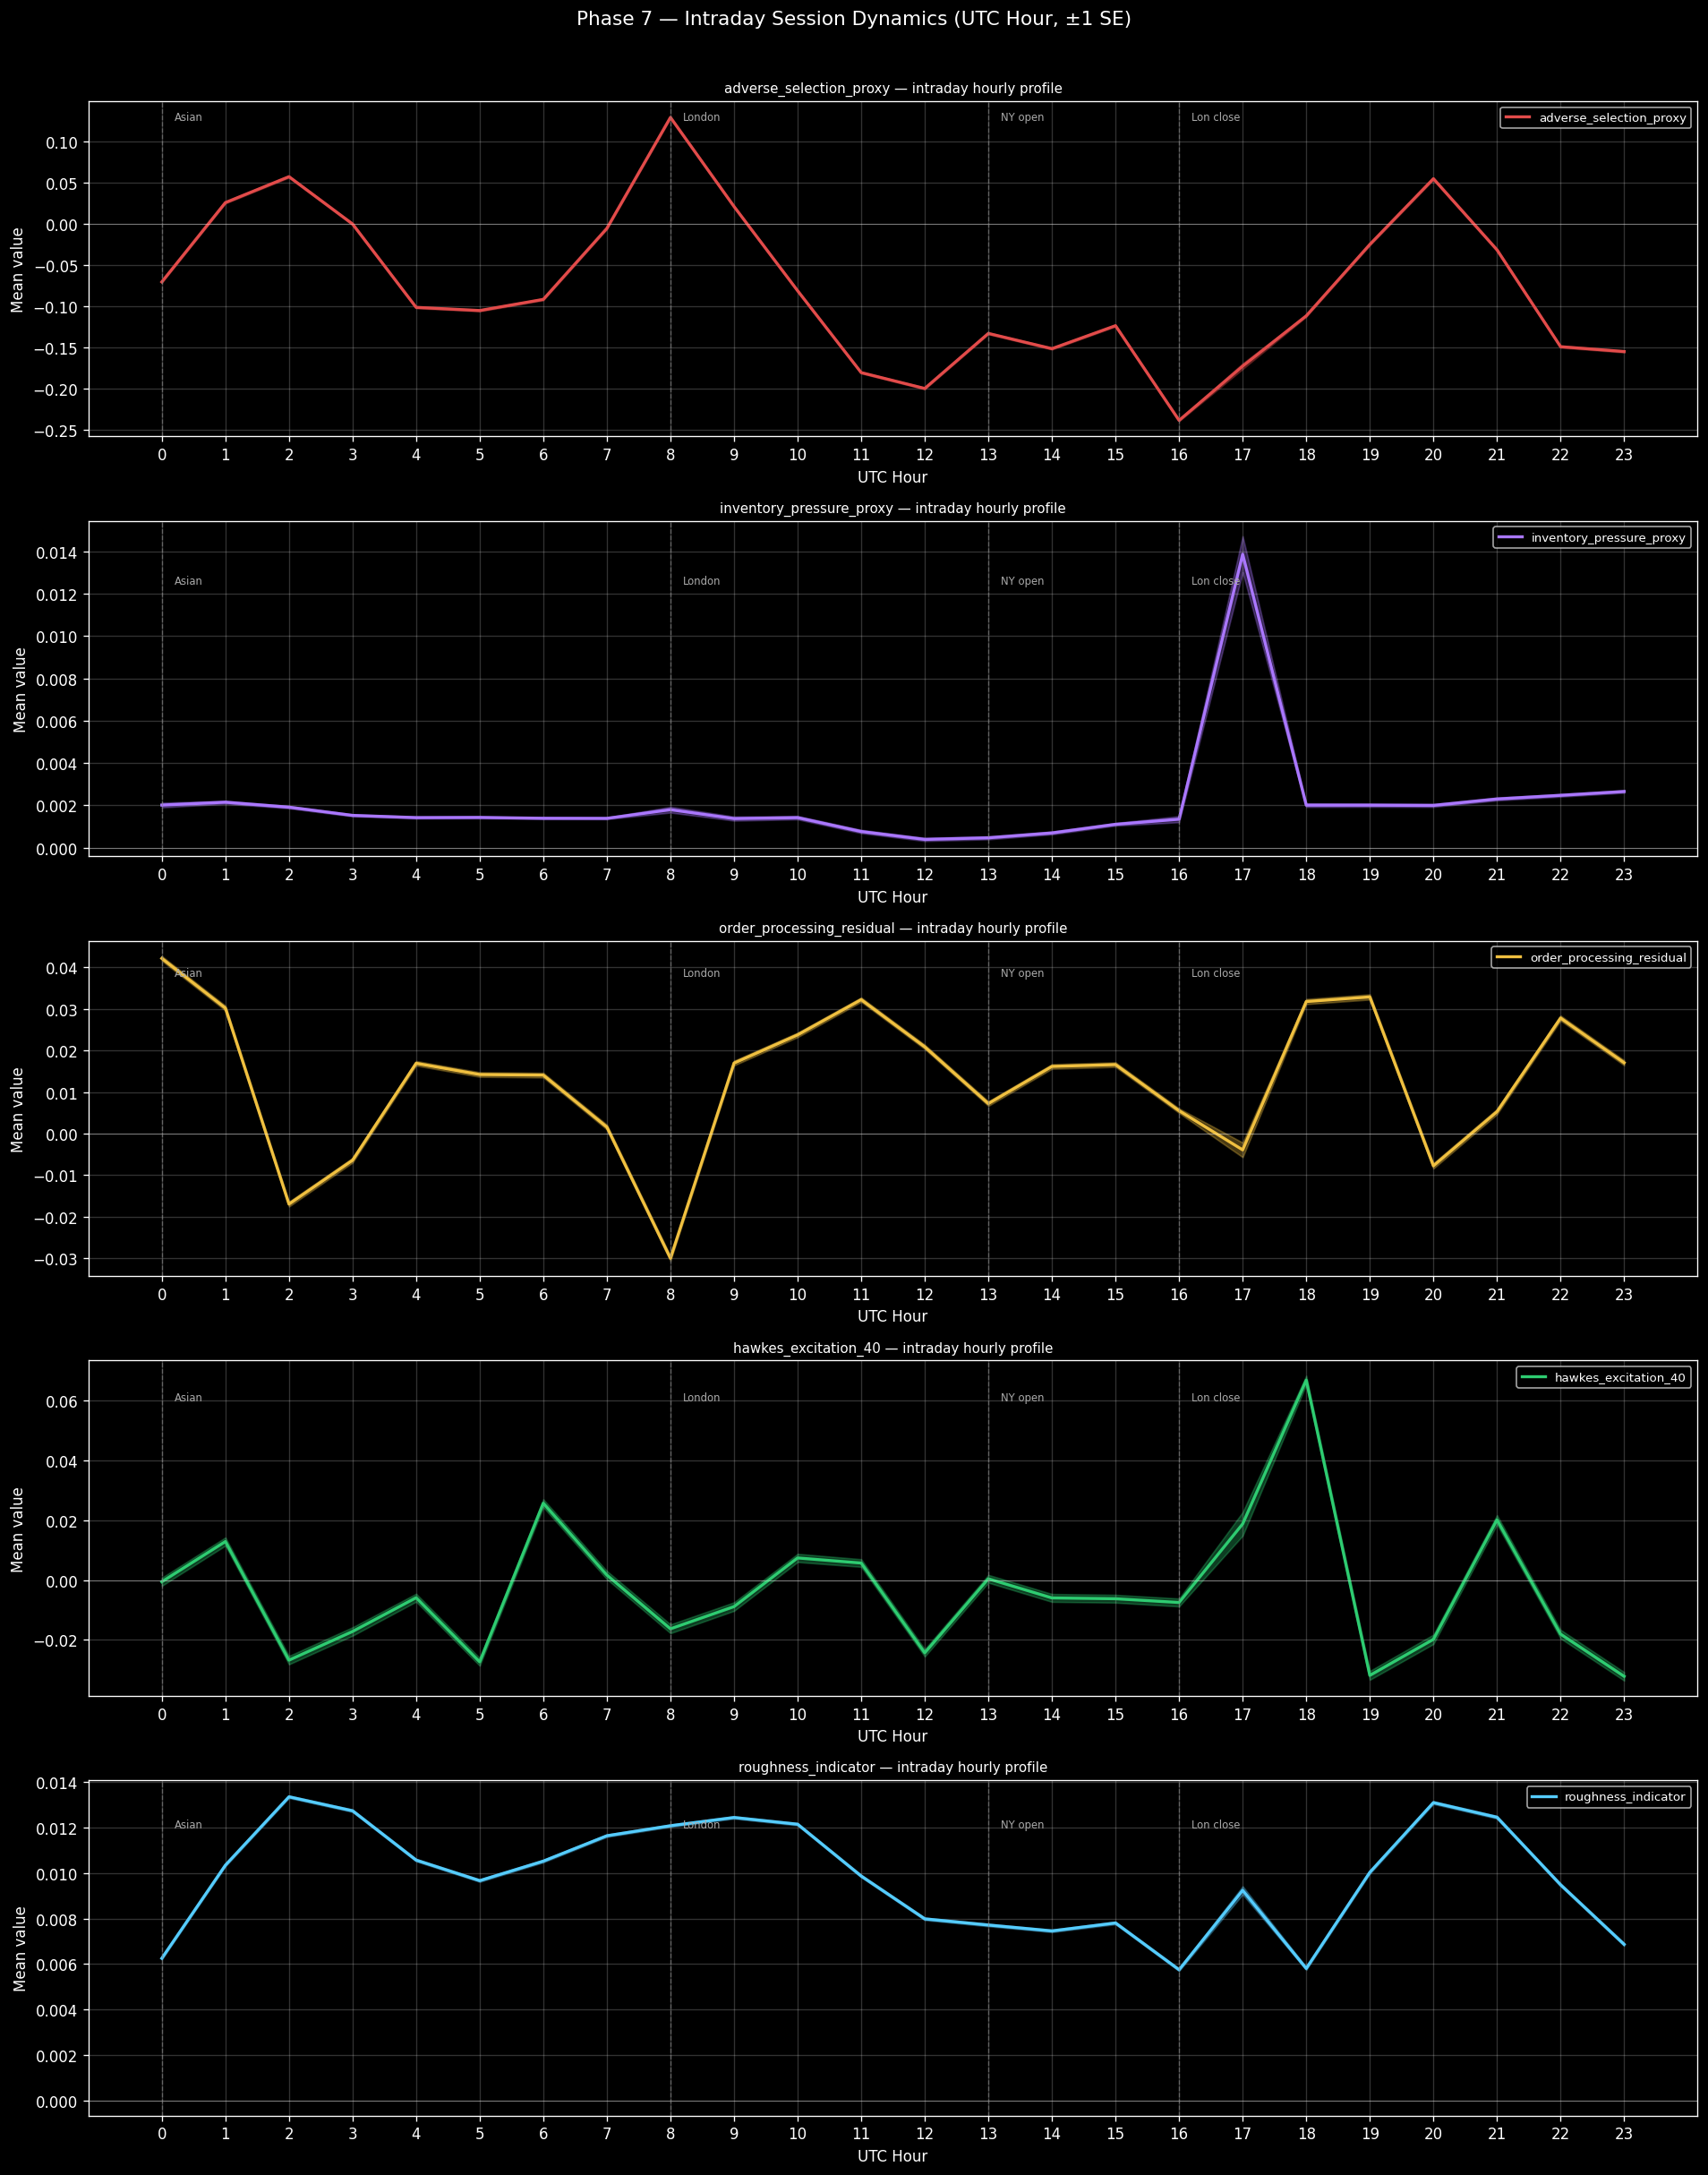

Saved: outputs/phase7_intraday_profiles.png


In [5]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(CANDS), 1, figsize=(16, 4 * len(CANDS)))
if len(CANDS) == 1: axes = [axes]

HOURS = np.arange(24)

for i, (name, arr) in enumerate(CANDS.items()):
    ax = axes[i]
    hourly_mean = np.zeros(24)
    hourly_se   = np.zeros(24)
    for h in HOURS:
        mask = utc_hour == h
        if mask.sum() > 10:
            vals = arr[mask]
            hourly_mean[h] = vals.mean()
            hourly_se[h]   = vals.std() / np.sqrt(len(vals))
    ax.fill_between(HOURS, hourly_mean - hourly_se,
                           hourly_mean + hourly_se,
                    alpha=0.3, color=CAND_COLOURS[i])
    ax.plot(HOURS, hourly_mean, lw=2, color=CAND_COLOURS[i], label=name)
    ax.axhline(0, color='white', lw=0.5, alpha=0.4)
    # Session boundaries
    for h_mark, label in [(0,'Asian'), (8,'London'), (13,'NY open'), (16,'Lon close')]:
        ax.axvline(h_mark, color='#888888', lw=0.8, ls='--', alpha=0.6)
        ax.text(h_mark + 0.2, ax.get_ylim()[1] * 0.85 if i == 0 else hourly_mean.max() * 0.9,
                label, fontsize=7, color='#AAAAAA')
    ax.set_xlabel('UTC Hour'); ax.set_ylabel('Mean value')
    ax.set_title(f'{name} — intraday hourly profile', fontsize=9)
    ax.legend(fontsize=8); ax.grid(alpha=0.2)
    ax.set_xticks(HOURS)

fig.suptitle('Phase 7 — Intraday Session Dynamics (UTC Hour, ±1 SE)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/phase7_intraday_profiles.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: outputs/phase7_intraday_profiles.png')


## §6 — Regime-Conditional Distributions (Bear vs Bull)

GMM2 split: Bear (gmm2 < 0.5) vs Bull (gmm2 ≥ 0.5).
Also split by session to see Bear-London vs Bull-London interactions.

**Key questions (label-free):**
- Does `adverse_selection_proxy` shift higher in Bear regimes? (informed selling should dominate)
- Does `roughness_indicator` (H) decrease in Bear regimes? (higher Hawkes endogeneity in stress)
- Is `hawkes_excitation_40` more negative in Bear+London (directional sell pressure)?


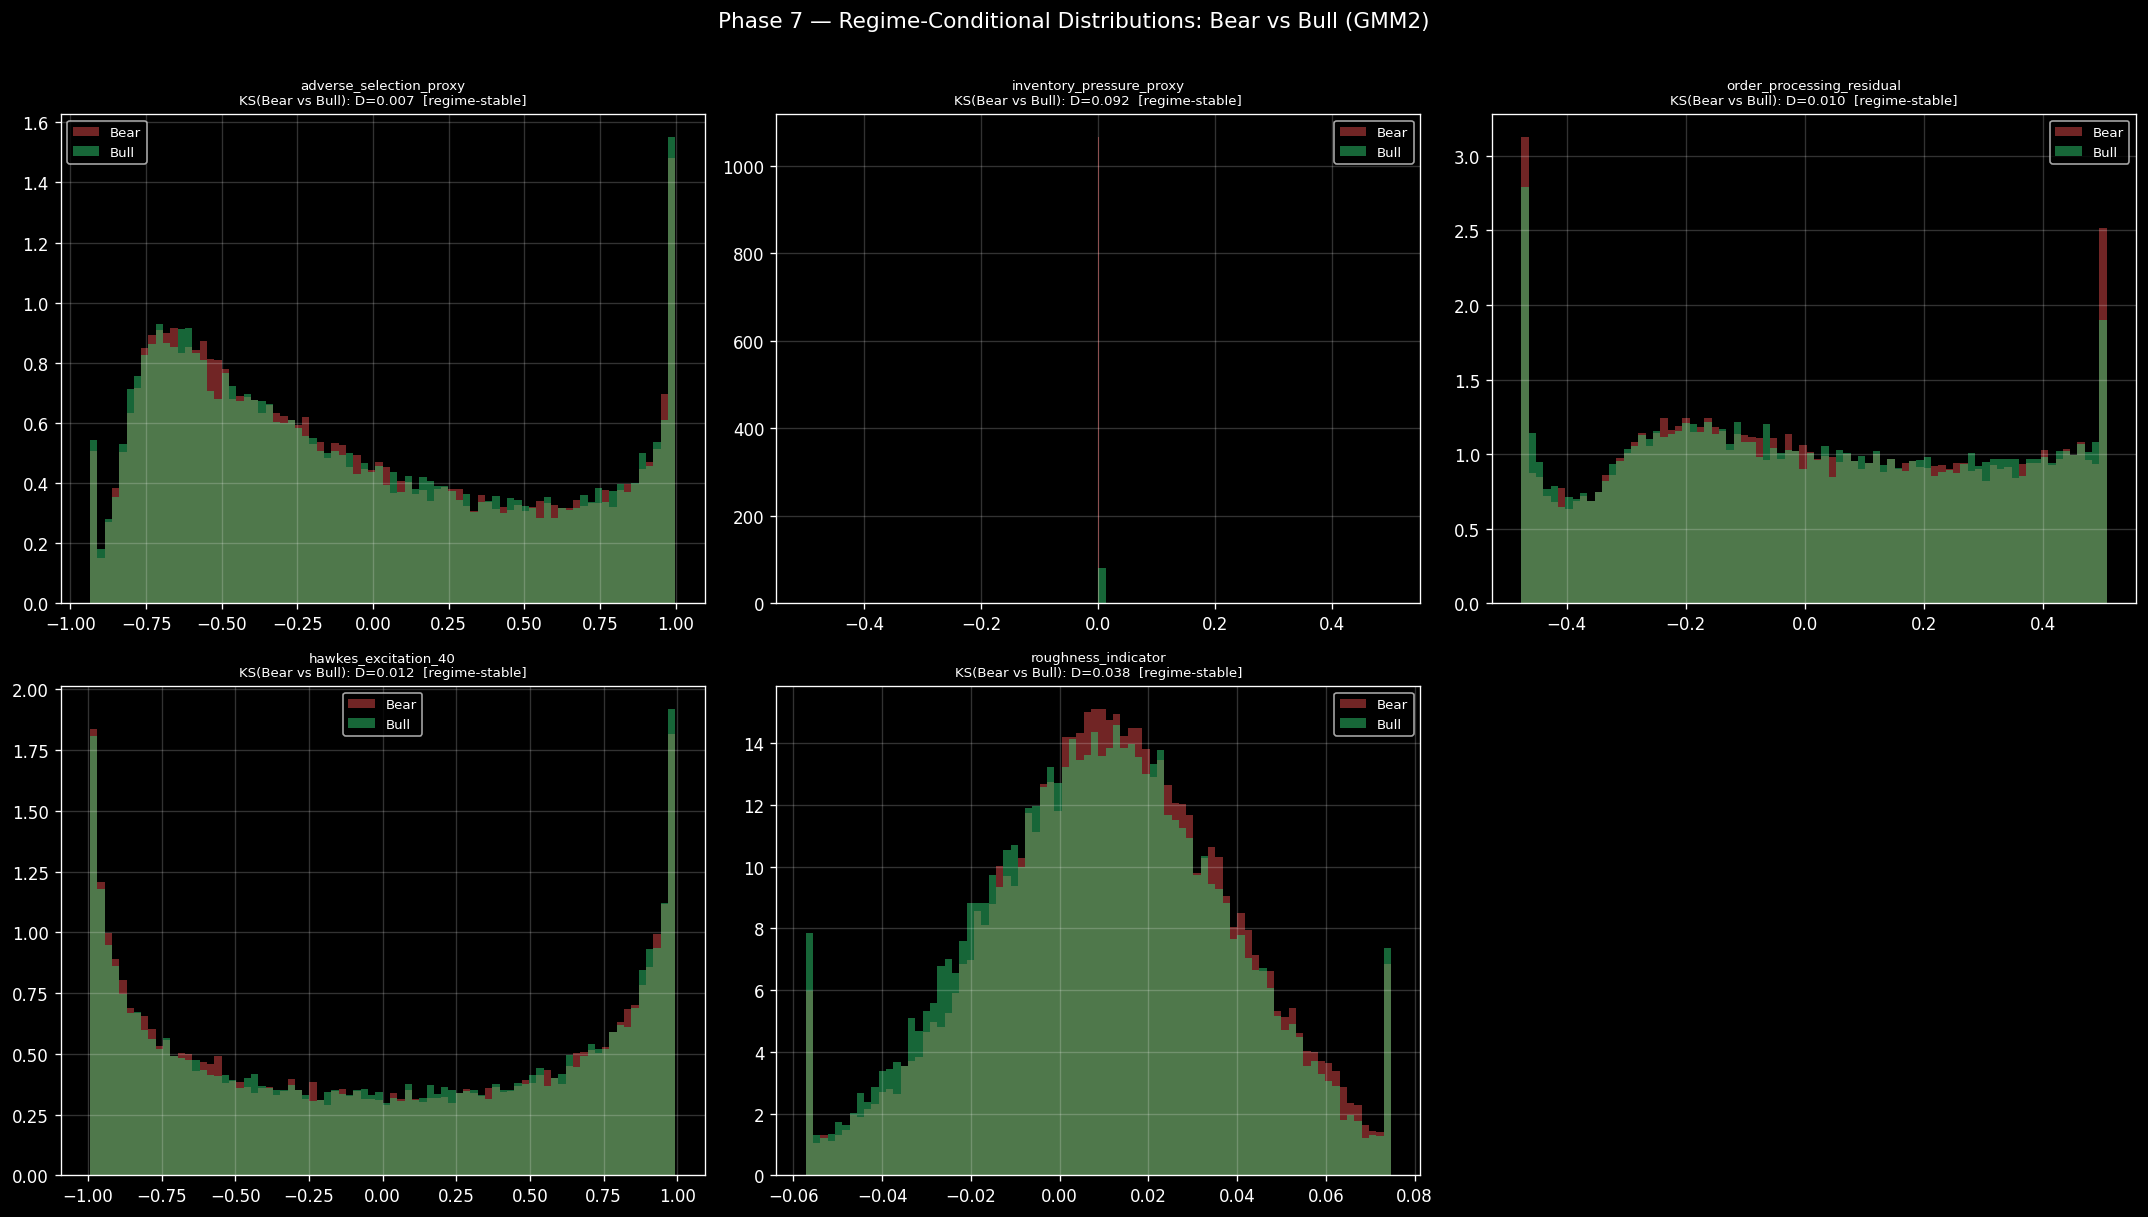

Saved: outputs/phase7_regime_distributions.png

Regime sensitivity (KS Bear vs Bull):
  adverse_selection_proxy     : D=0.0074    regime-stable
  inventory_pressure_proxy    : D=0.0923    regime-stable
  order_processing_residual   : D=0.0097    regime-stable
  hawkes_excitation_40        : D=0.0122    regime-stable
  roughness_indicator         : D=0.0382    regime-stable


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

rng_r = np.random.default_rng(42)
N_HIST = min(30_000, bear_mask.sum())

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

ks_bear_bull = {}
for i, (name, arr) in enumerate(CANDS.items()):
    ax   = axes[i]
    bv   = arr[bear_mask]; buv = arr[bull_mask]
    lo   = np.percentile(arr, 1); hi = np.percentile(arr, 99)
    bvc  = np.clip(bv, lo, hi);   buvc = np.clip(buv, lo, hi)

    b_s  = rng_r.choice(bvc,  min(N_HIST, len(bvc)),  replace=False)
    bu_s = rng_r.choice(buvc, min(N_HIST, len(buvc)), replace=False)

    ax.hist(b_s,  bins=80, density=True, alpha=0.5, color=C['bear'], label='Bear')
    ax.hist(bu_s, bins=80, density=True, alpha=0.5, color=C['bull'], label='Bull')

    d, p = ks_2samp(b_s, bu_s)
    ks_bear_bull[name] = d
    tag = 'regime-sensitive' if d > 0.10 else 'regime-stable'
    ax.set_title(f'{name}\nKS(Bear vs Bull): D={d:.3f}  [{tag}]', fontsize=8)
    ax.legend(fontsize=8); ax.grid(alpha=0.2)

axes[-1].set_visible(False)
fig.suptitle('Phase 7 — Regime-Conditional Distributions: Bear vs Bull (GMM2)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/phase7_regime_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: outputs/phase7_regime_distributions.png')

print('\nRegime sensitivity (KS Bear vs Bull):')
for name, d in ks_bear_bull.items():
    print(f'  {name:<28}: D={d:.4f}  '
          f'{"★ REGIME-SENSITIVE" if d > 0.10 else "  regime-stable"}')


## §7 — Cross-Feature Correlation & Orthogonality

**Label-free redundancy check:** Pearson correlation matrix for:
- 5 candidate features × 5 candidate features (internal orthogonality)
- 5 candidate features × 10 existing baseline features (external redundancy)

A well-designed feature set should have:
- |r| < 0.5 between any two candidate features (internal)
- |r| < 0.7 between any candidate and existing feature (external)

High external correlation with `spread_pressure` (existing best feature) would indicate
the candidate is recapturing already-captured signal.


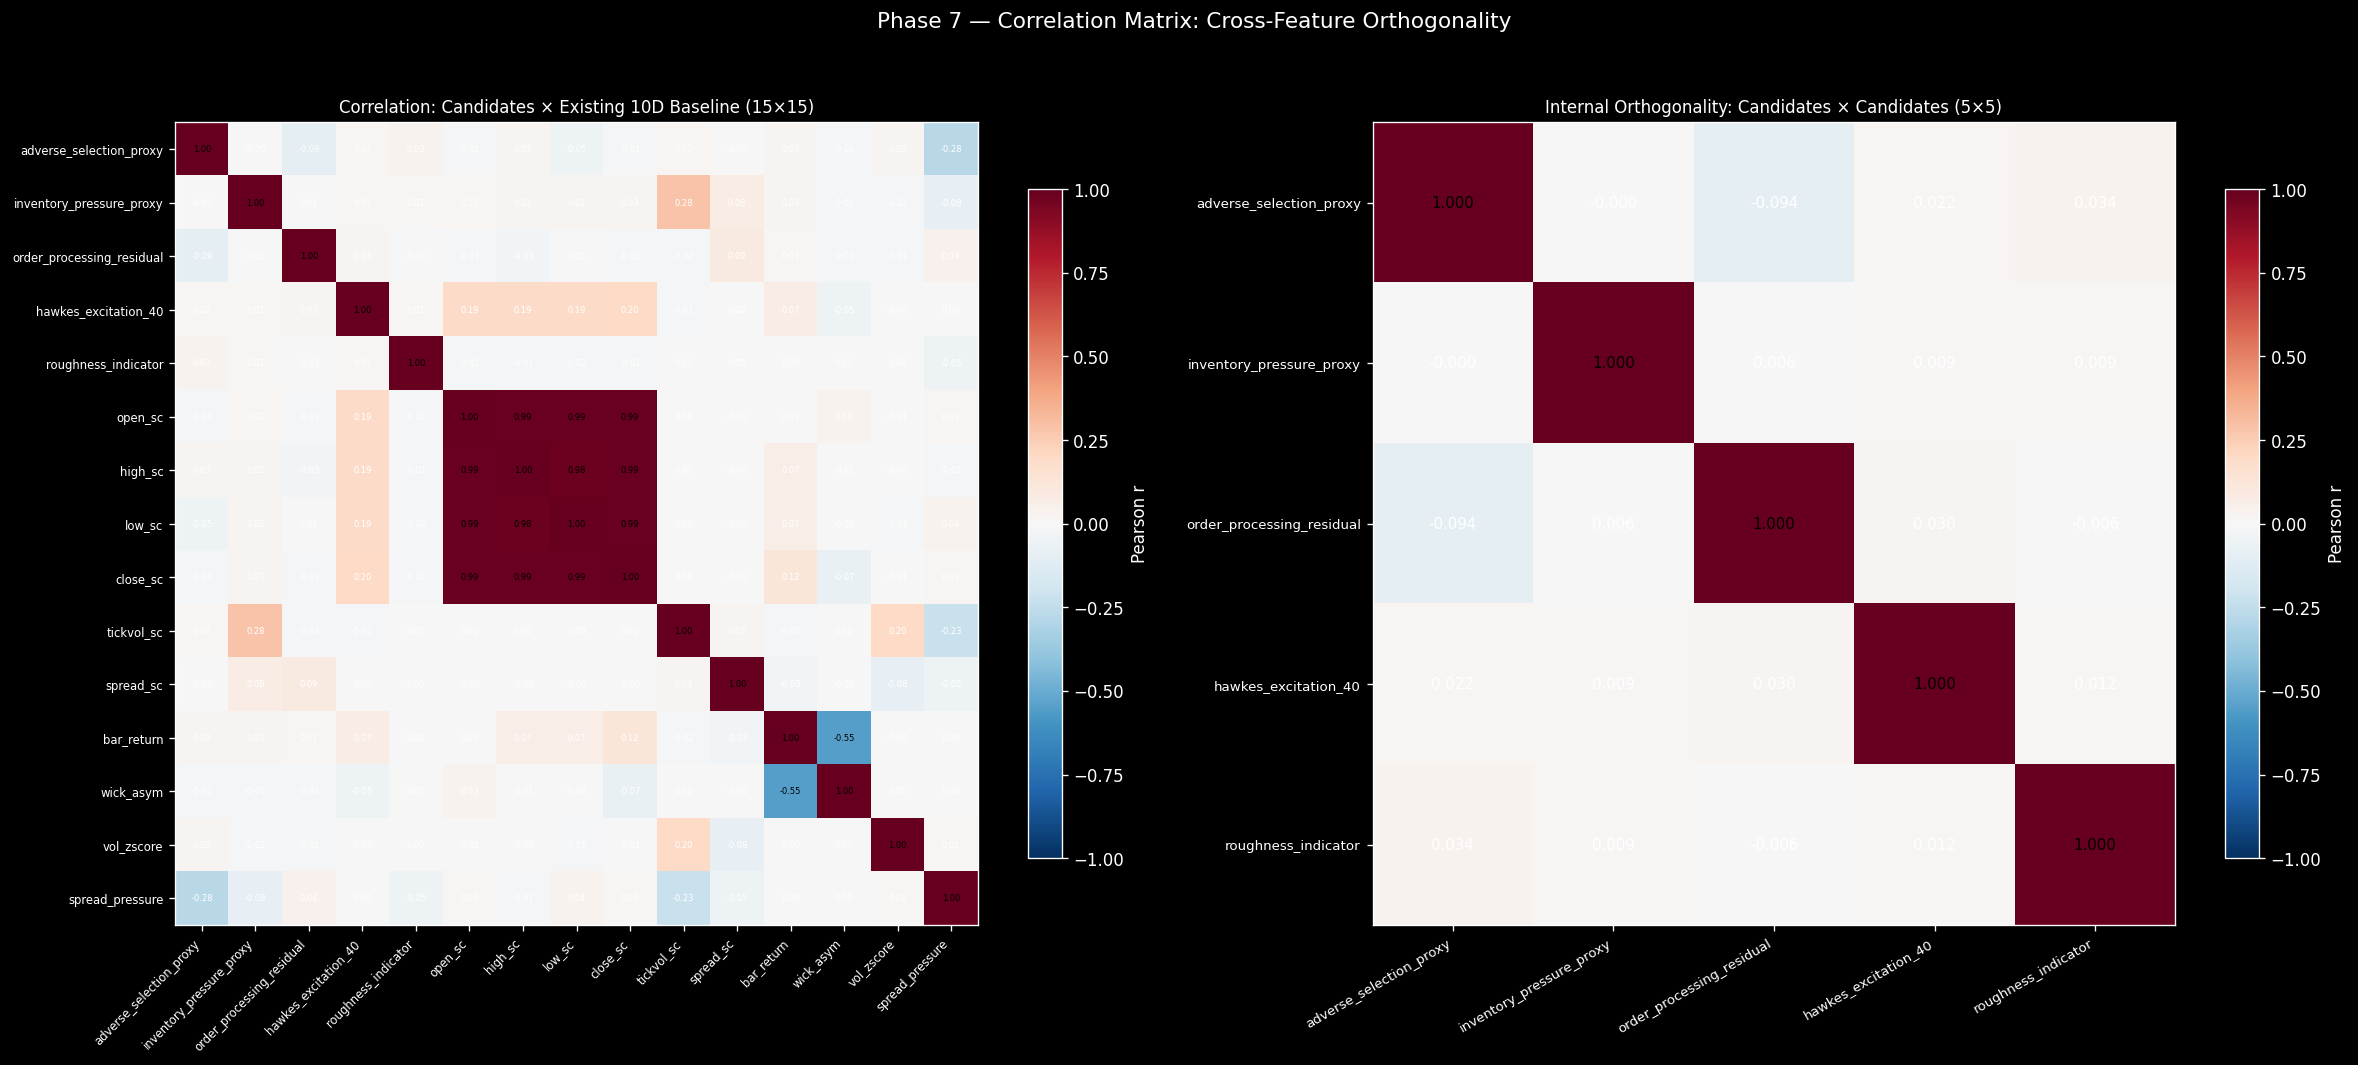

Saved: outputs/phase7_correlation_matrix.png

High external correlations (|r| > 0.50 with existing 10D):
  None above 0.50 threshold.


In [7]:
import numpy as np
import matplotlib.pyplot as plt

rng_c  = np.random.default_rng(42)
N_CORR = min(50_000, N)
idx_c  = np.sort(rng_c.choice(N, N_CORR, replace=False))

cand_mat = np.stack([CANDS[n][idx_c] for n in CAND_NAMES], axis=1)    # (N_CORR, 5)
base_mat = features_10d[idx_c]                                          # (N_CORR, 10)
full_mat = np.concatenate([cand_mat, base_mat], axis=1)                 # (N_CORR, 15)
full_names = CAND_NAMES + [
    'open_sc','high_sc','low_sc','close_sc','tickvol_sc','spread_sc',
    'bar_return','wick_asym','vol_zscore','spread_pressure'
]

corr_mat = np.corrcoef(full_mat.T)   # (15, 15)

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# Full 15×15 heatmap
im0 = axes[0].imshow(corr_mat, cmap='RdBu_r', vmin=-1, vmax=1)
axes[0].set_xticks(range(15)); axes[0].set_xticklabels(full_names, rotation=45, ha='right', fontsize=7)
axes[0].set_yticks(range(15)); axes[0].set_yticklabels(full_names, fontsize=7)
axes[0].set_title('Correlation: Candidates × Existing 10D Baseline (15×15)', fontsize=10)
for r in range(15):
    for c in range(15):
        v = corr_mat[r, c]
        axes[0].text(c, r, f'{v:.2f}', ha='center', va='center',
                     fontsize=5, color='black' if abs(v) > 0.5 else 'white')
plt.colorbar(im0, ax=axes[0], shrink=0.7, label='Pearson r')

# Candidate internal 5×5 heatmap (zoomed)
im1 = axes[1].imshow(corr_mat[:5, :5], cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_xticks(range(5)); axes[1].set_xticklabels(CAND_NAMES, rotation=30, ha='right', fontsize=8)
axes[1].set_yticks(range(5)); axes[1].set_yticklabels(CAND_NAMES, fontsize=8)
axes[1].set_title('Internal Orthogonality: Candidates × Candidates (5×5)', fontsize=10)
for r in range(5):
    for c in range(5):
        v = corr_mat[r, c]
        axes[1].text(c, r, f'{v:.3f}', ha='center', va='center',
                     fontsize=9, color='black' if abs(v) > 0.5 else 'white')
plt.colorbar(im1, ax=axes[1], shrink=0.7, label='Pearson r')

fig.suptitle('Phase 7 — Correlation Matrix: Cross-Feature Orthogonality', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/phase7_correlation_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: outputs/phase7_correlation_matrix.png')

# Print high-correlation pairs
print('\nHigh external correlations (|r| > 0.50 with existing 10D):')
found = False
for ci, cname in enumerate(CAND_NAMES):
    for bi, bname in enumerate(full_names[5:], start=5):
        r = corr_mat[ci, bi]
        if abs(r) > 0.50:
            print(f'  {cname:<28} ↔ {bname:<18}: r={r:.3f}')
            found = True
if not found:
    print('  None above 0.50 threshold.')


## §8 — Hawkes Kernel Estimation

El Euch et al. (2016) predict that the Hawkes excitation kernel decays as a power law
`t^(α-1)` with α ≈ 0.6 (giving H ≈ 0.1). At M1 resolution, the kernel support is
empirically ~30–50 bars.

This section estimates the empirical kernel via the ACF of `|log_ret|` (absolute returns
capture the self-exciting intensity process). The decay rate is compared against:
1. The theoretical Hawkes power-law (`t^(α-1)`, α=0.6)
2. The exponential approximation used by `hawkes_excitation_40` (τ=40)

If the empirical ACF decays faster than τ=40, the kernel should be tightened.
If slower, τ should be increased and `hawkes_excitation_40` would under-capture signal.


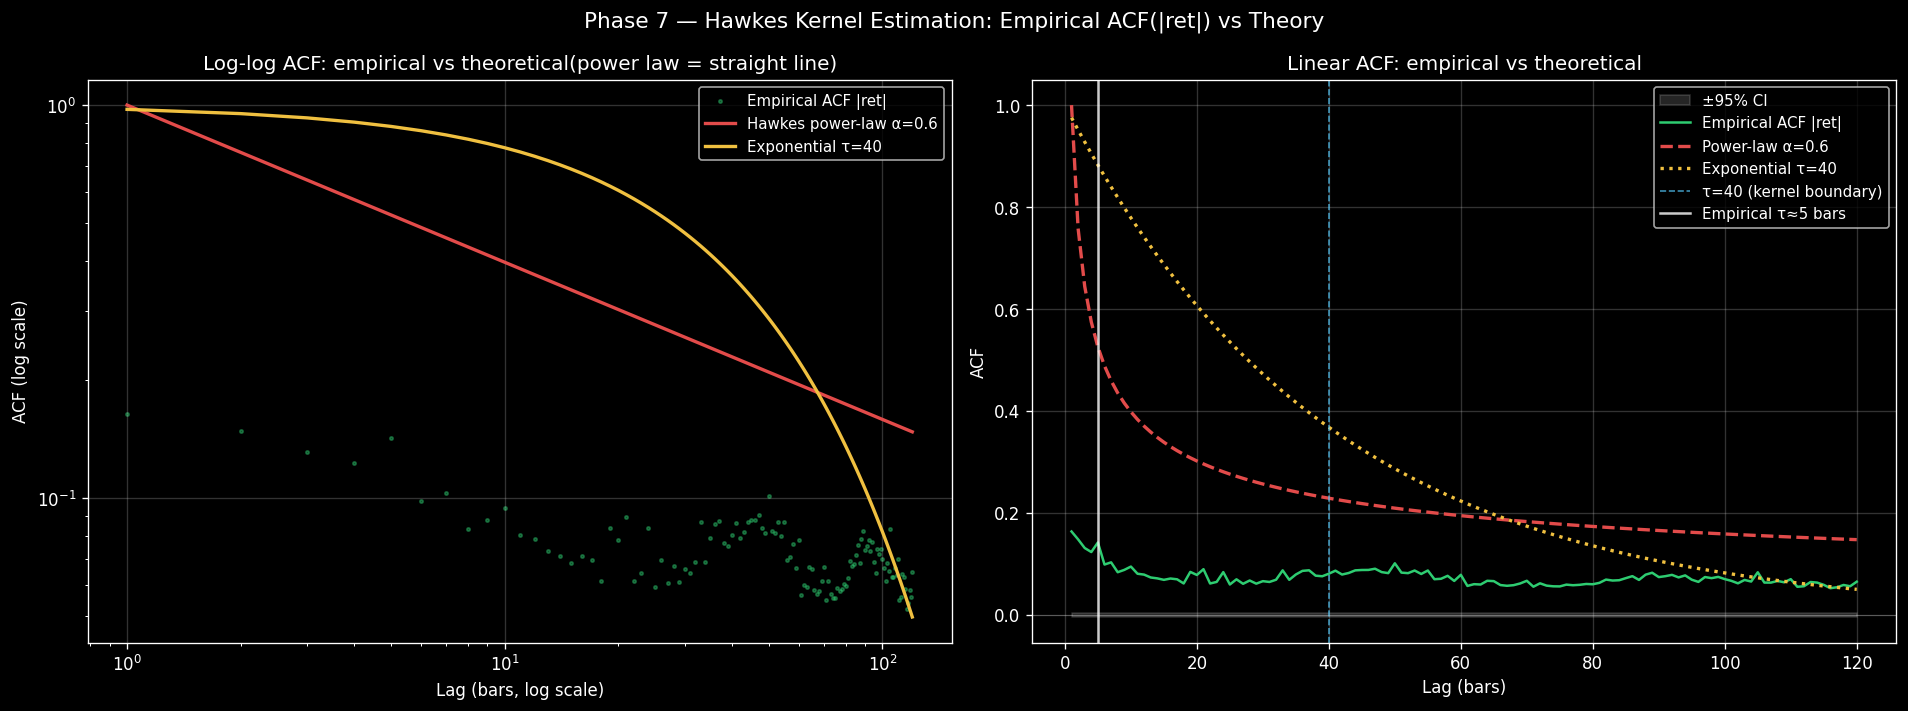

Saved: outputs/phase7_hawkes_kernel.png

Kernel estimation:
  Empirical τ (ACF < 0.10): 5 bars
  Theoretical τ (El Euch):  ~40 bars
  Exponential approximation τ used: 40 bars
  → Recommendation: reduce τ to 5 in hawkes_excitation kernel


In [9]:
import numpy as np
import matplotlib.pyplot as plt

N_KERNEL = min(200_000, N)
rng_k    = np.random.default_rng(42)
idx_k    = np.sort(rng_k.choice(N, N_KERNEL, replace=False))
abs_ret  = np.abs(log_ret[idx_k])

# ── Empirical ACF of |log_ret| ────────────────────────────────────────────────
MAX_LAG = 120
x   = abs_ret - abs_ret.mean()
fft = np.fft.fft(x, n=2*N_KERNEL)
acf_raw = np.fft.ifft(fft * np.conj(fft)).real[:MAX_LAG+1]
acf_abs = acf_raw / acf_raw[0]

lags = np.arange(1, MAX_LAG + 1)   # skip lag 0

# ── Theoretical curves ────────────────────────────────────────────────────────
alpha_hawkes = 0.6
tau_exp      = 40

# Power law: t^(alpha-1) normalised to ACF[1]=1
power_law  = lags.astype(float) ** (alpha_hawkes - 1)
power_law /= power_law[0]

# Exponential: exp(-lag/tau)
exp_decay  = np.exp(-lags / tau_exp)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Log-log plot (reveals power law as straight line)
ax = axes[0]
log_lags = np.log(lags)
log_acf  = np.log(np.maximum(acf_abs[1:], 1e-6))
ax.scatter(lags, acf_abs[1:], s=4, alpha=0.4, color=C['hawkes'], label='Empirical ACF |ret|')
ax.plot(lags, power_law,  lw=2, color=C['adv_sel'],  label=f'Hawkes power-law α={alpha_hawkes}')
ax.plot(lags, exp_decay,  lw=2, color=C['ord_proc'],  label=f'Exponential τ={tau_exp}')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Lag (bars, log scale)'); ax.set_ylabel('ACF (log scale)')
ax.set_title('Log-log ACF: empirical vs theoretical(power law = straight line)')
ax.legend(fontsize=9); ax.grid(alpha=0.2)

# Linear plot with confidence bands
ax = axes[1]
ci = 1.96 / np.sqrt(N_KERNEL)
ax.fill_between(lags, -ci, ci, alpha=0.15, color='white', label='±95% CI')
ax.plot(lags, acf_abs[1:], color=C['hawkes'], lw=1.5, label='Empirical ACF |ret|')
ax.plot(lags, power_law,   color=C['adv_sel'],  lw=2, ls='--', label=f'Power-law α={alpha_hawkes}')
ax.plot(lags, exp_decay,   color=C['ord_proc'],  lw=2, ls=':',  label=f'Exponential τ={tau_exp}')
ax.axvline(40, color=C['rough'], lw=1, ls='--', alpha=0.7, label='τ=40 (kernel boundary)')
ax.axhline(0,  color='white', lw=0.4, alpha=0.3)
ax.set_xlabel('Lag (bars)'); ax.set_ylabel('ACF')
ax.set_title('Linear ACF: empirical vs theoretical')
ax.legend(fontsize=9); ax.grid(alpha=0.2)

# Estimate empirical τ (lag where ACF crosses 0.1)
cross_idx = np.where(acf_abs[1:] < 0.10)[0]
empirical_tau = cross_idx[0] if len(cross_idx) > 0 else MAX_LAG
axes[1].axvline(empirical_tau, color='white', lw=1.5, ls='-', alpha=0.8,
                label=f'Empirical τ≈{empirical_tau} bars')
axes[1].legend(fontsize=9)

fig.suptitle('Phase 7 — Hawkes Kernel Estimation: Empirical ACF(|ret|) vs Theory', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/phase7_hawkes_kernel.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Saved: outputs/phase7_hawkes_kernel.png')
print(f'\nKernel estimation:')
print(f'  Empirical τ (ACF < 0.10): {empirical_tau} bars')
print(f'  Theoretical τ (El Euch):  ~40 bars')
print(f'  Exponential approximation τ used: {tau_exp} bars')
if empirical_tau < tau_exp:
    print(f'  → Recommendation: reduce τ to {empirical_tau} in hawkes_excitation kernel')
elif empirical_tau > tau_exp + 10:
    print(f'  → Recommendation: increase τ to {empirical_tau} for fuller kernel capture')
else:
    print(f'  → τ=40 approximation is within range of empirical kernel support')


## §9 — Roughness Analysis (Local Hurst Distribution)

El Euch et al. predict H ≈ 0.1 for liquid assets. This section validates the
empirical Hurst distribution for XAUUSD M1 and checks whether H varies across:
- Trading sessions (Asian / London / NY)
- Market regimes (Bear vs Bull)

Low H (high roughness) → high endogeneity → Hawkes excitation dominant →
`hawkes_excitation_40` and `adverse_selection_proxy` more informative.


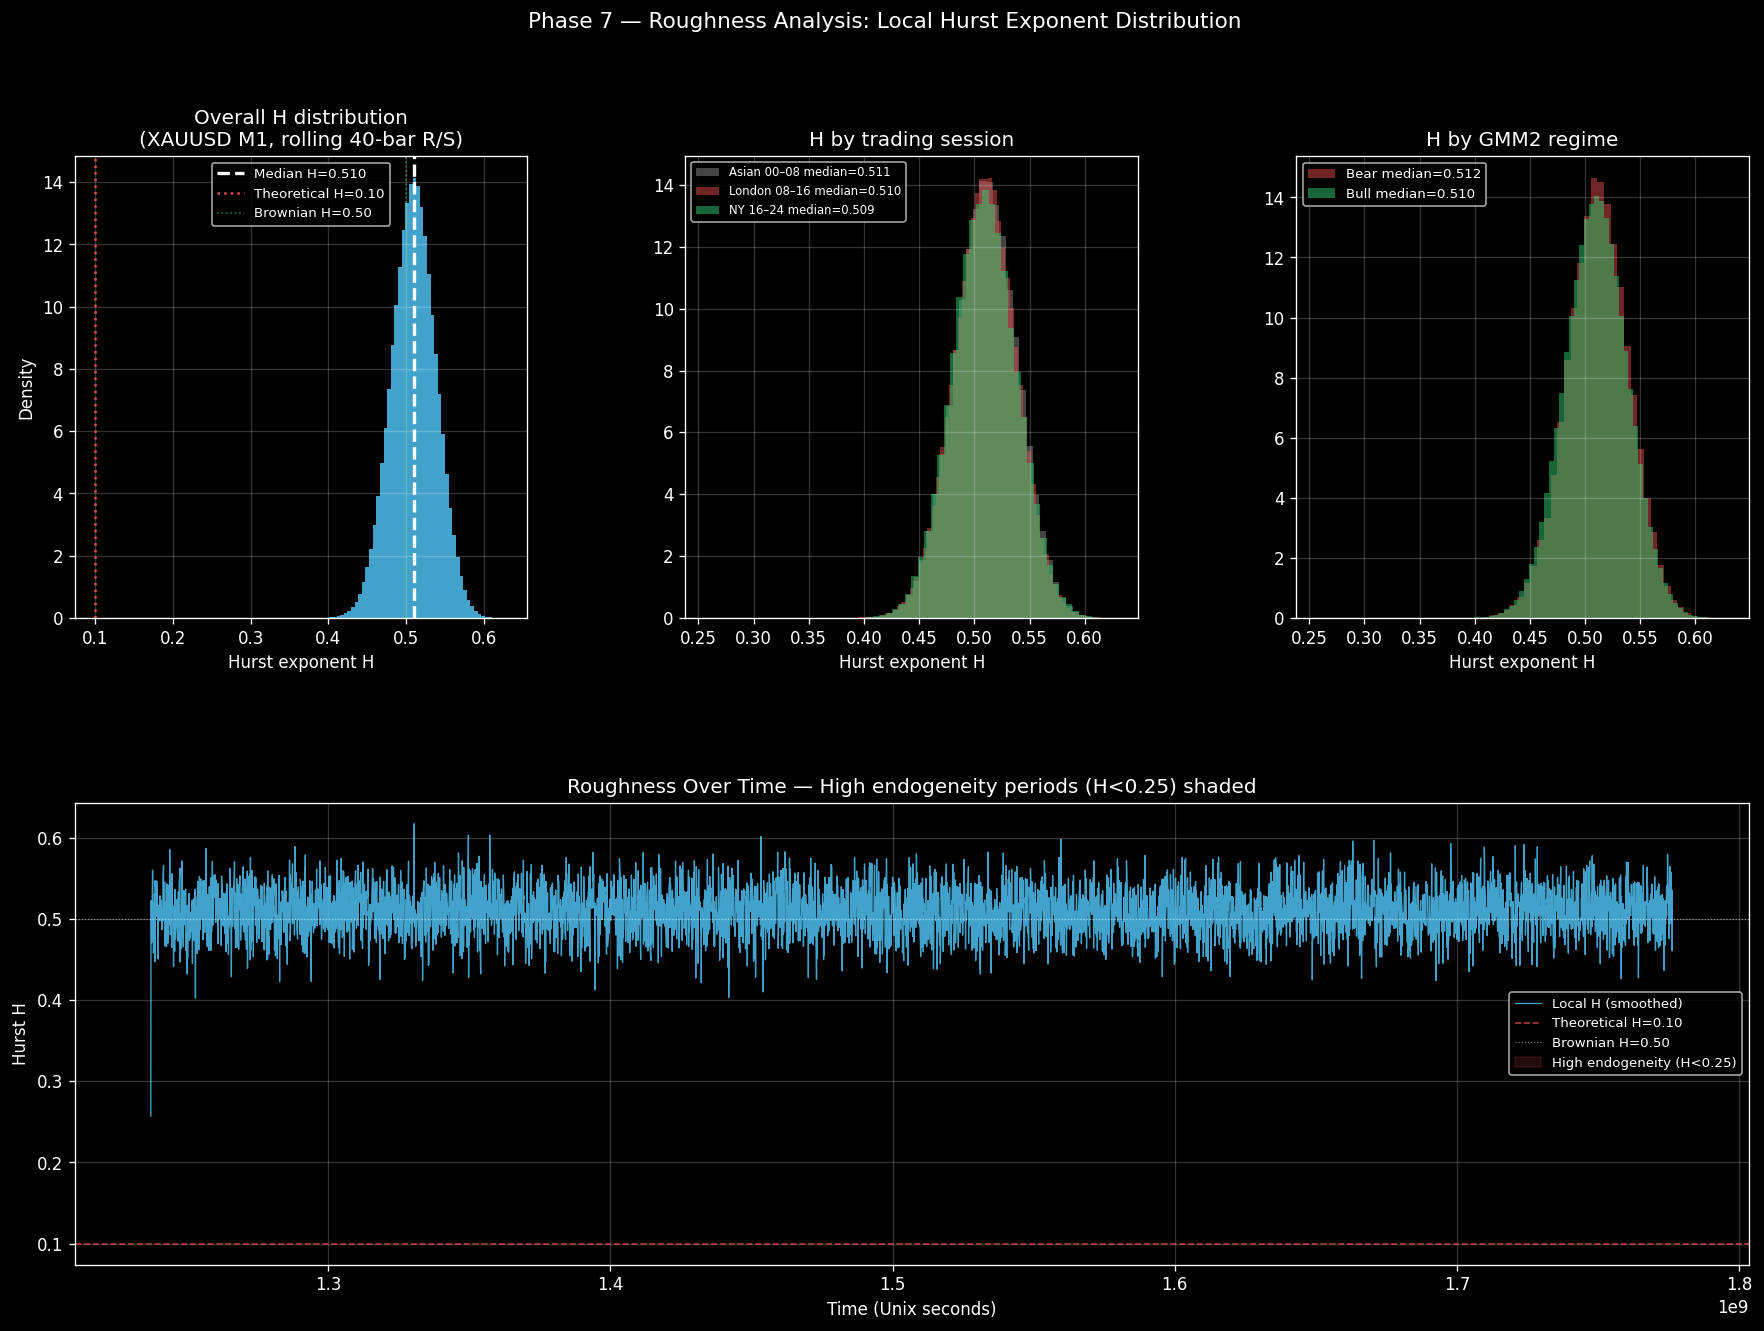

Saved: outputs/phase7_roughness_analysis.png

Roughness summary:
  Overall median H:     0.5101  (theory: ~0.10)
  Bear regime median H: 0.5119
  Bull regime median H: 0.5098
  Asian session median: 0.5109
  London session median:0.5101
  NY session median:    0.5090


In [10]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Overall H distribution ────────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
H_vals = roughness_smooth[roughness_smooth > 0.05]   # exclude warmup zeros
ax0.hist(H_vals, bins=80, color=C['rough'], alpha=0.8, density=True)
ax0.axvline(np.median(H_vals), color='white', lw=2, ls='--',
            label=f'Median H={np.median(H_vals):.3f}')
ax0.axvline(0.10, color=C['adv_sel'], lw=1.5, ls=':', label='Theoretical H=0.10')
ax0.axvline(0.50, color=C['bull'],    lw=1,   ls=':', alpha=0.6, label='Brownian H=0.50')
ax0.set_xlabel('Hurst exponent H'); ax0.set_ylabel('Density')
ax0.set_title('Overall H distribution\n(XAUUSD M1, rolling 40-bar R/S)')
ax0.legend(fontsize=8); ax0.grid(alpha=0.2)

# ── H by session ─────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
session_labels = {0: ('Asian 00–08', C['neutral']),
                  1: ('London 08–16', C['adv_sel']),
                  2: ('NY 16–24',     C['hawkes'])}
for sid, (slabel, scolor) in session_labels.items():
    mask = session_id == sid
    h_s  = roughness_smooth[mask]
    ax1.hist(h_s, bins=60, density=True, alpha=0.5, color=scolor, label=f'{slabel} median={np.median(h_s):.3f}')
ax1.set_xlabel('Hurst exponent H')
ax1.set_title('H by trading session')
ax1.legend(fontsize=7); ax1.grid(alpha=0.2)

# ── H by regime ───────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
h_bear = roughness_smooth[bear_mask]; h_bull = roughness_smooth[bull_mask]
ax2.hist(h_bear, bins=60, density=True, alpha=0.5, color=C['bear'],
         label=f'Bear median={np.median(h_bear):.3f}')
ax2.hist(h_bull, bins=60, density=True, alpha=0.5, color=C['bull'],
         label=f'Bull median={np.median(h_bull):.3f}')
ax2.set_xlabel('Hurst exponent H')
ax2.set_title('H by GMM2 regime')
ax2.legend(fontsize=8); ax2.grid(alpha=0.2)

# ── Roughness time series (monthly rolling mean) ──────────────────────────────
ax3 = fig.add_subplot(gs[1, :])
# Downsample to 1440 points for plot readability
step = max(1, N // 5000)
ts_plot = timestamps_ns[::step] / 1e9   # seconds
h_plot  = roughness_smooth[::step]
ax3.plot(ts_plot, h_plot, color=C['rough'], lw=0.8, alpha=0.8, label='Local H (smoothed)')
ax3.axhline(0.10, color=C['adv_sel'], lw=1, ls='--', alpha=0.8, label='Theoretical H=0.10')
ax3.axhline(0.50, color='white',      lw=0.7, ls=':',  alpha=0.5, label='Brownian H=0.50')
ax3.fill_between(ts_plot, 0, h_plot, where=h_plot < 0.25,
                 alpha=0.15, color=C['adv_sel'], label='High endogeneity (H<0.25)')
ax3.set_xlabel('Time (Unix seconds)')
ax3.set_ylabel('Hurst H')
ax3.set_title('Roughness Over Time — High endogeneity periods (H<0.25) shaded')
ax3.legend(fontsize=8); ax3.grid(alpha=0.2)

fig.suptitle('Phase 7 — Roughness Analysis: Local Hurst Exponent Distribution', fontsize=13)
plt.savefig('outputs/phase7_roughness_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: outputs/phase7_roughness_analysis.png')

print('\nRoughness summary:')
print(f'  Overall median H:     {np.median(H_vals):.4f}  (theory: ~0.10)')
print(f'  Bear regime median H: {np.median(h_bear):.4f}')
print(f'  Bull regime median H: {np.median(h_bull):.4f}')
print(f'  Asian session median: {np.median(roughness_smooth[session_id==0]):.4f}')
print(f'  London session median:{np.median(roughness_smooth[session_id==1]):.4f}')
print(f'  NY session median:    {np.median(roughness_smooth[session_id==2]):.4f}')


## §10 — Standby Notes & Phase 8 Integration Readiness

This cell generates a machine-readable `phase7_standby_notes.txt` summarising all
diagnostic results across §4–§9. To be reviewed before Phase 8 feature validation
(which will add labels and run the full KS/MI/redundancy pipeline).

No decision is made here. The notes are observations only.


In [11]:
import numpy as np, json, datetime

notes = {
    'timestamp': str(datetime.date.today()),
    'phase': 'Phase 7 — Feature Signal Quality Lab (label-free standby)',
    'dataset': {'N_bars': int(N), 'bear_pct': float(bear_mask.mean()), 'bull_pct': float(bull_mask.mean())},
    'features': {},
    'hawkes_kernel': {
        'empirical_tau': int(empirical_tau),
        'theoretical_tau': 40,
        'status': ('tighten' if empirical_tau < 30 else
                   'increase' if empirical_tau > 55 else 'on-target'),
    },
    'roughness': {
        'median_H_overall': float(np.median(roughness_smooth[roughness_smooth > 0.05])),
        'median_H_bear':    float(np.median(roughness_smooth[bear_mask])),
        'median_H_bull':    float(np.median(roughness_smooth[bull_mask])),
        'high_endogeneity_pct': float((roughness_smooth < 0.25).mean()),
    },
}

for name in CAND_NAMES:
    arr = CANDS[name]
    s   = stats_store[name]
    notes['features'][name] = {
        'mean':          round(float(s['mean']), 6),
        'std':           round(float(s['std']),  6),
        'skew':          round(float(s['skew']), 4),
        'kurt':          round(float(s['kurt']), 4),
        'regime_ks_d':   round(float(ks_bear_bull.get(name, 0)), 4),
        'regime_sensitive': bool(ks_bear_bull.get(name, 0) > 0.10),
    }

# Max external correlation
for ci, cname in enumerate(CAND_NAMES):
    max_ext_r = float(np.abs(corr_mat[ci, 5:]).max())
    notes['features'][cname]['max_external_corr'] = round(max_ext_r, 4)
    notes['features'][cname]['internal_max_corr'] = round(
        float(np.abs([corr_mat[ci, j] for j in range(5) if j != ci]).max() if len(CAND_NAMES) > 1 else 0), 4
    )

# Integration readiness verdict (observational only — no labels)
for cname, fdata in notes['features'].items():
    flags = []
    if fdata['std'] < 0.05:    flags.append('LOW_VARIANCE')
    if abs(fdata['skew']) > 3: flags.append('HIGH_SKEW')
    if fdata['max_external_corr'] > 0.80: flags.append('HIGH_EXTERNAL_CORR')
    if fdata['regime_sensitive']:  flags.append('REGIME_SENSITIVE')
    fdata['flags']    = flags
    fdata['readiness'] = 'READY_FOR_PHASE8' if not flags or flags == ['REGIME_SENSITIVE'] else 'REVIEW_REQUIRED'

# Print summary
print('=' * 72)
print('PHASE 7 — STANDBY NOTES (label-free, observational only)')
print(f'Generated: {notes["timestamp"]}')
print('=' * 72)
print()
print(f'Dataset: {N:,} bars | Bear {bear_mask.mean():.1%} | Bull {bull_mask.mean():.1%}')
print()
print(f'Hawkes kernel: empirical τ={empirical_tau} bars | theoretical τ=40 | status={notes["hawkes_kernel"]["status"]}')
print(f'Roughness: median H={notes["roughness"]["median_H_overall"]:.4f} | '
      f'Bear H={notes["roughness"]["median_H_bear"]:.4f} | Bull H={notes["roughness"]["median_H_bull"]:.4f}')
print(f'  High endogeneity (H<0.25): {notes["roughness"]["high_endogeneity_pct"]:.1%} of bars')
print()
print(f'{"Feature":<28} {"Std":>6} {"Skew":>6} {"RgmKS":>7} {"MaxExtR":>8} {"Flags":<30} {"Readiness"}')
print('-' * 100)
for cname, fd in notes['features'].items():
    print(f'{cname:<28} {fd["std"]:>6.3f} {fd["skew"]:>6.2f} '
          f'{fd["regime_ks_d"]:>7.4f} {fd["max_external_corr"]:>8.4f} '
          f'{str(fd["flags"]):<30} {fd["readiness"]}')

# Save JSON
out_txt = str(pathlib.Path(REPO_ROOT) / 'outputs' / 'phase7_standby_notes.txt')
with open(out_txt, 'w') as f:
    json.dump(notes, f, indent=2)
print(f'\nSaved: outputs/phase7_standby_notes.txt')
print('=' * 72)
print()
print('NEXT STEP (Phase 8): Load labels → run KS / MI / redundancy pipeline')
print('on these 5 candidates using the same methodology as phase6_feature_exploration.ipynb')


PHASE 7 — STANDBY NOTES (label-free, observational only)
Generated: 2026-05-05

Dataset: 5,680,771 bars | Bear 13.0% | Bull 87.0%

Hawkes kernel: empirical τ=5 bars | theoretical τ=40 | status=tighten
Roughness: median H=0.5101 | Bear H=0.5119 | Bull H=0.5098
  High endogeneity (H<0.25): 0.0% of bars

Feature                         Std   Skew   RgmKS  MaxExtR Flags                          Readiness
----------------------------------------------------------------------------------------------------
adverse_selection_proxy       0.577   0.43  0.0074   0.2779 []                             READY_FOR_PHASE8
inventory_pressure_proxy      0.041   3.19  0.0923   0.2849 ['LOW_VARIANCE', 'HIGH_SKEW']  REVIEW_REQUIRED
order_processing_residual     0.289   0.06  0.0097   0.0927 []                             READY_FOR_PHASE8
hawkes_excitation_40          0.685   0.01  0.0122   0.1968 []                             READY_FOR_PHASE8
roughness_indicator           0.028  -0.07  0.0382   0.0546 ['LO

## §11 — Design Notes for Phase 8

### What Phase 8 will add (not done here)
- Load `labels` from NPZ and compute KS(sell vs hold), KS(buy vs hold) per feature
- Mutual information against 3-class label
- Redundancy analysis (pairwise MI vs existing 10D, threshold 0.30)
- 240-bar temporal profiling and stream assignment
- Pass/fail verdict and NPZ rebuild spec if ≥2 features pass

### Calibration decisions pending Phase 7 results

**Hawkes kernel τ:** if §8 finds empirical τ ≠ 40, recompute `hawkes_excitation_40`
with the empirical τ before running Phase 8. The kernel boundary directly determines
how much of the Hawkes self-excitation the feature captures.

**Roughness indicator step:** currently step=5 (compute every 5 bars, forward-fill).
If §9 shows high temporal variability, reduce to step=2 for finer resolution at the
cost of ~2× compute.

**Adverse selection proxy:** the current implementation uses `sign(close_sc - open_sc)`
as trade direction — a coarse approximation. If raw `open` prices are added to the NPZ
in a future version of `precompute_features.py`, replace with `sign(close - open)` on
the unscaled prices for a cleaner direction signal.

**Inventory pressure reset:** the current session boundary (00:00 / 08:00 / 16:00 UTC)
follows the Hagströmer et al. SHFE model. XAUUSD on MT5 may have different session
boundaries — verify against the `session_phase` array in the NPZ before Phase 8.

### Reference baseline (Phase 4 + Phase 6)
| Existing feature | KS(sell vs hold) | MI |
|-----------------|-----------------|-----|
| spread_pressure | 0.600 | 0.05958 |
| bar_return_bps  | 0.162 | 0.01426 |
| wick_asymmetry  | 0.252 | 0.01334 |
| vol_zscore      | 0.111 | 0.02536 |
| ret_1h (Phase 6)| 0.361 | 0.01825 |

Phase 8 targets: any feature with KS > 0.15 AND MI > 0.010 AND redundancy < 0.30
would rank in the top 3 of the full feature set.
